In [1]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from tqdm import tqdm
from torchmetrics.functional import accuracy

device = 'cuda' if torch.cuda.is_available() else 'cpu'
#device = 'cpu'
torch.backends.cudnn.benchmark = True
BATCH_SIZE = 64
EPOCHS = 6

# Definindo os Datasets
Alguns datasets comuns encontram-se diretamente em torchvision.datasets

Podemos definir os conjuntos de treino e teste da seguinte forma.

In [2]:
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

# Visualizando o dataset
Podemos visualizar algumas instâncias do nosso conjunto de dados

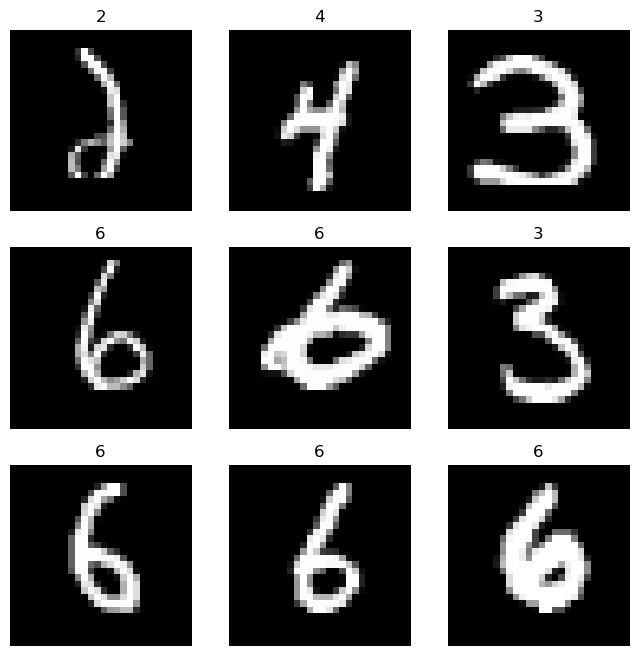

In [3]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [4]:

train_dataloader = DataLoader(training_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Dataloaders: {train_dataloader, test_dataloader}") 
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x00000217922B54E0>, <torch.utils.data.dataloader.DataLoader object at 0x00000217922B4700>)
Length of train dataloader: 938 batches of 64
Length of test dataloader: 157 batches of 64


In [5]:
x, y = next(iter(test_dataloader))
print(x.shape, y.shape)

torch.Size([64, 1, 28, 28]) torch.Size([64])


In [6]:
class LeNet5(torch.nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = torch.nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2)
        self.conv2 = torch.nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
        self.fc1 = torch.nn.Linear(16*5*5, 120)
        self.fc2 = torch.nn.Linear(120, 84)
        self.fc3 = torch.nn.Linear(84, 10)
        
    def forward(self, x):
        x = torch.max_pool2d(torch.relu(self.conv1(x)), 2)
        x = torch.max_pool2d(torch.relu(self.conv2(x)), 2)
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [7]:
torch.manual_seed(42)
lenet5 = LeNet5()
lenet5.to(device)

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [8]:
loss_fn = torch.nn.CrossEntropyLoss() 
optimizer = torch.optim.SGD(params=lenet5.parameters(), lr=0.1)

In [9]:
def train_step(model, dataloader, loss_fn, optimizer, device: torch.device):
    train_loss = 0
    # Faz loop em todos os dados de treino
    for X, y in dataloader:
        
        X, y = X.to(device), y.to(device)
        model.train() 
        # 1. Forward pass
        y_pred = model(X)

        # 2. Calcula loss por batch
        loss = loss_fn(y_pred, y)
        train_loss += loss 

        # 3. zera gradientes anteriores
        optimizer.zero_grad()

        # 4. Backward Pass
        loss.backward()

        # 5. Otimizacao
        optimizer.step()

    train_loss /= len(dataloader)
    return train_loss


In [10]:
def test_step(model:torch.nn.Module, loss_fn:torch.nn.Module, dataloader:torch.utils.data.DataLoader, device:torch.device):
    test_loss, test_acc = 0, 0 
    model.eval()
    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            # 1. Forward pass
            test_pred = model(X)
        
            # 2. Loss
            test_loss += loss_fn(test_pred, y) # accumulatively add up the loss per epoch

            # 3. Computa a acuracia
            test_acc += accuracy(target=y,
                                 preds=torch.softmax(test_pred,dim=1),
                                 task='multiclass',
                                 num_classes=10)
        
        test_loss /= len(dataloader)
        test_acc /= len(dataloader)
        return test_loss, test_acc

In [11]:
torch.manual_seed(42)
for epoch in range(EPOCHS):
    with tqdm(train_dataloader, desc=f'{epoch=}', unit='batch') as tqdm_epoch:
        train_loss = train_step(lenet5, tqdm_epoch, loss_fn, optimizer, device)
        test_loss, test_acc = test_step(lenet5, loss_fn, test_dataloader, device)
        
    print(f'Train loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc*100:.4f}%')


epoch=0: 100%|██████████| 938/938 [00:16<00:00, 57.28batch/s] 


Train loss: 0.42733 | Test loss: 0.09237, Test acc: 97.0541%


epoch=1: 100%|██████████| 938/938 [00:12<00:00, 75.18batch/s] 


Train loss: 0.07909 | Test loss: 0.05613, Test acc: 98.3380%


epoch=2: 100%|██████████| 938/938 [00:12<00:00, 74.95batch/s] 


...

Train loss: 0.04465 | Test loss: 0.05246, Test acc: 98.2285%


epoch=4: 100%|██████████| 938/938 [00:15<00:00, 58.86batch/s] 


Train loss: 0.03577 | Test loss: 0.02953, Test acc: 99.0545%


epoch=5: 100%|██████████| 938/938 [00:18<00:00, 51.57batch/s] 


Train loss: 0.02981 | Test loss: 0.04002, Test acc: 98.7361%


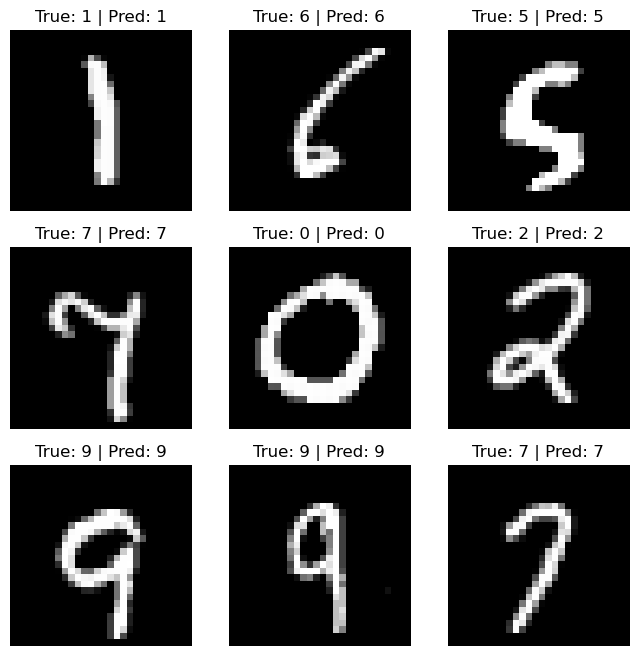

In [12]:
idxs = torch.randint(len(training_data), size=(1,10))
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = idxs[0,i].item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    predicted = torch.argmax(lenet5(img.unsqueeze(0).to(device)))
    plt.title(f'True: {label} | Pred: {predicted}')
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [13]:
img, label = training_data[sample_idx]

In [14]:
img.shape

torch.Size([1, 28, 28])

In [15]:
feature_map1 = torch.relu(lenet5.conv1(img.unsqueeze(0).to(device)))
feature_map2 = torch.max_pool2d(feature_map1,2)
feature_map3 = torch.relu(lenet5.conv2(feature_map2))
feature_map4 = torch.max_pool2d(feature_map3,2)
feature_map5 = torch.flatten(feature_map4,1)
feature_map6 = torch.relu(lenet5.fc1(feature_map5))
feature_map7 = torch.relu(lenet5.fc2(feature_map6))
feature_map8 = lenet5.fc3(feature_map7)
torch.softmax(feature_map8, dim=1)

tensor([[2.5738e-07, 7.1805e-05, 2.8227e-05, 6.7618e-05, 2.3108e-06, 4.6113e-07,
         1.3358e-09, 9.9980e-01, 6.7821e-07, 3.0009e-05]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)